# Structured Output

In [2]:
# To get the output from the LLM in a specific format (json, list, list of json, nested json, nested list, etc)

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser, PydanticOutputParser
from langchain_openai import ChatOpenAI

c:\Users\YashwanthKumar\Downloads\Yash\Github\GenAI-Basics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Weak Approach

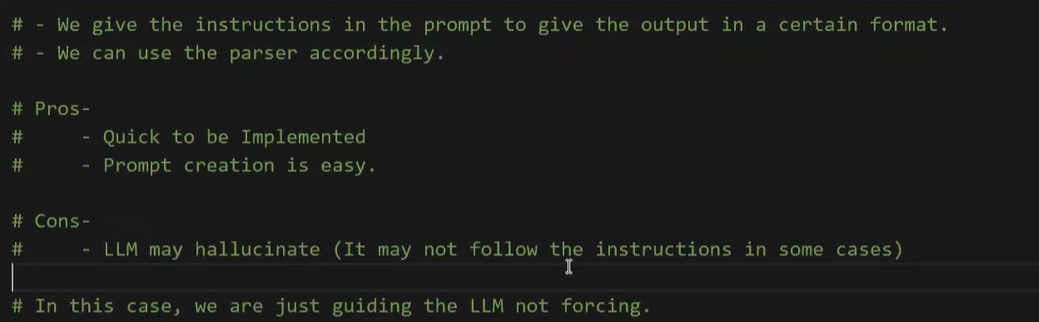

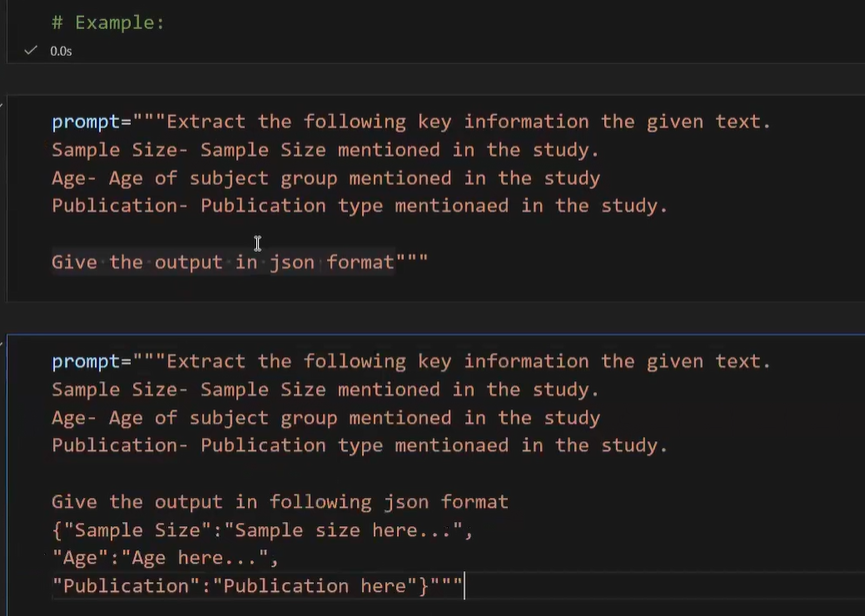

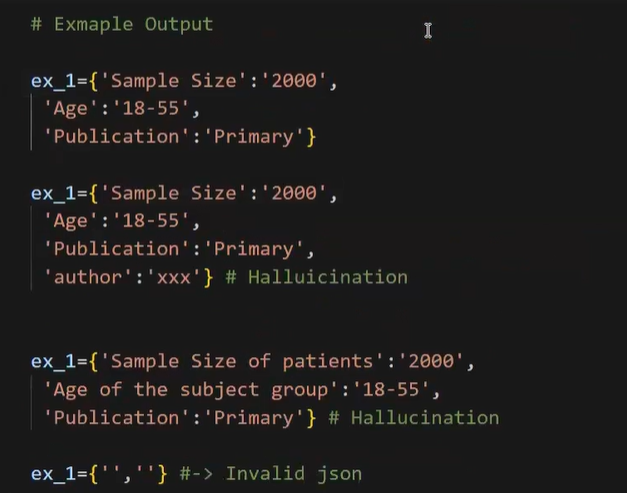

## 2) Strong Approach

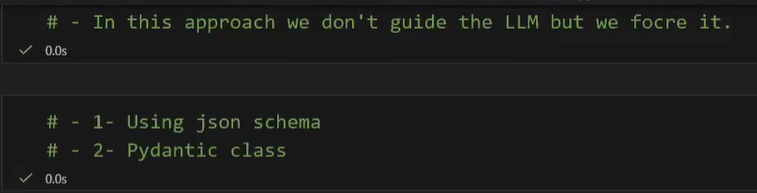

### Json Schema

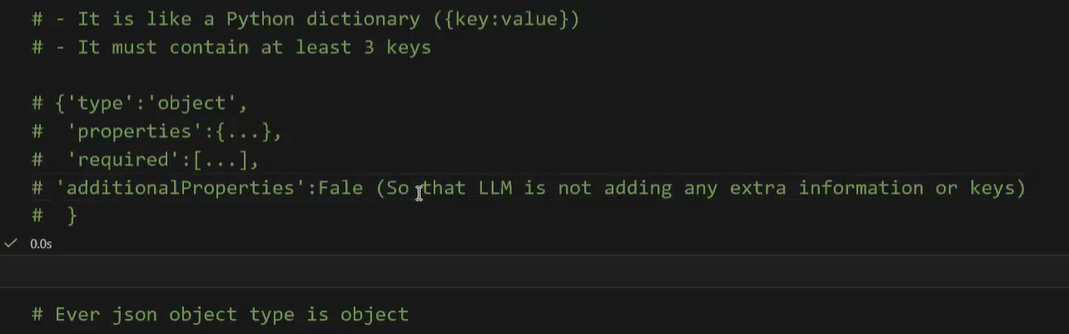

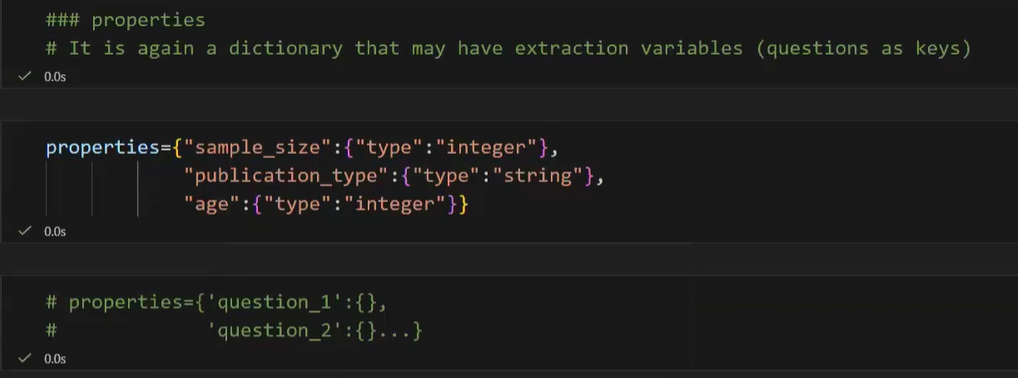

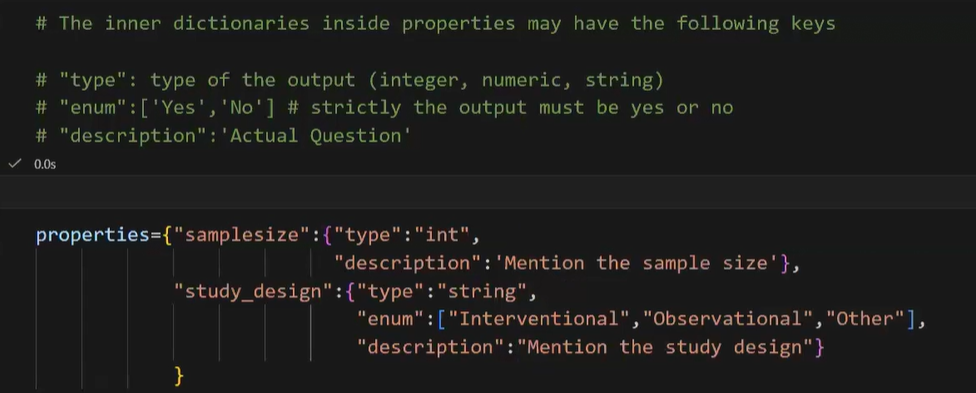

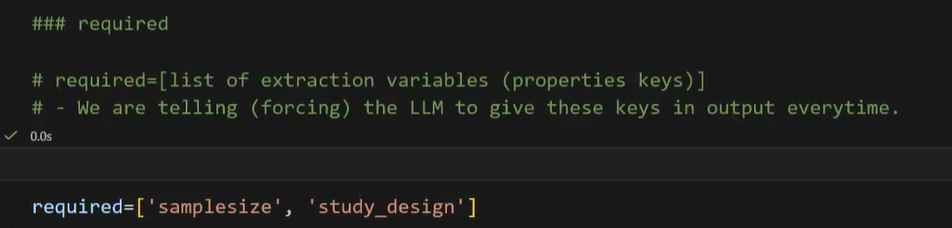

In [3]:
json_schema  = {
    "type": "object",
    "properties": {
        "name": {
            "type": "string",
            "description": "What is the name of the algorithm?",
        },
        "type": {
            "type": "string",
            "enum": [
                "Supervised",
                "Unsupervised",
                "Both",
                "Other"
            ],
            "description": "Explain the type of the algorithm."
        },
        "use_cases": {
            "type": "integer",
            "enum": [0, 1, 2],
            "description": "Explain the type of the problem that algorithms solves. Mention 1 for Regression, 2 for Classification, and 3 for others."
        }
    },
    "required": ["name", "type", "use_cases"],
    "additionalProperties": False
}

### How to use Json Schema with LLMs

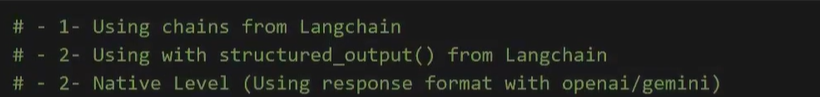

#### 1) Using Chains

In [ ]:
prompt = ChatPromptTemplate.from_messages([
    ('system', 'You are an Data Science & AI expert.'),
    ('human', '''Explain the following algorithm {algorithm}
        Give the output that follows the following json schema.
        JSON SCHEMA {schema}''')
]).partial(schema = json_schema)

# json schema is passed as an instruction (guiding but not forcing). This is another way to pass the input variable.

In [11]:
prompt

ChatPromptTemplate(input_variables=['algorithm'], input_types={}, partial_variables={'schema': {'type': 'object', 'properties': {'name': {'type': 'string', 'description': 'What is the name of the algorithm?'}, 'type': {'type': 'string', 'enum': ['Supervised', 'Unsupervised', 'Both', 'Other'], 'description': 'Explain the type of the algorithm.'}, 'use_cases': {'type': 'integer', 'enum': [0, 1, 2], 'description': 'Explain the type of the problem that algorithms solves. Mention 1 for Regression, 2 for Classification, and 3 for others.'}}, 'required': ['name', 'type', 'use_cases'], 'additionalProperties': False}}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Data Science & AI expert.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['algorithm', 'schema'], input_types={}, partial_variables={}, template='Explain the following algorithm {algorithm}\n        

In [ ]:
# prompt.format_messages(algorithm='Random Forest')

[SystemMessage(content='You are an Data Science & AI expert.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content="Explain the following algorithm Random Forest\n        Give the output that follows the following json schema.\n        JSON SCHEMA {'type': 'object', 'properties': {'name': {'type': 'string', 'description': 'What is the name of the algorithm?'}, 'type': {'type': 'string', 'enum': ['Supervised', 'Unsupervised', 'Both', 'Other'], 'description': 'Explain the type of the algorithm.'}, 'use_cases': {'type': 'integer', 'enum': [0, 1, 2], 'description': 'Explain the type of the problem that algorithms solves. Mention 1 for Regression, 2 for Classification, and 3 for others.'}}, 'required': ['name', 'type', 'use_cases'], 'additionalProperties': False}", additional_kwargs={}, response_metadata={})]

In [14]:
import os

In [15]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                    model='gpt-4o-mini')

In [17]:
# create chain

chain = prompt | llm
chain

ChatPromptTemplate(input_variables=['algorithm'], input_types={}, partial_variables={'schema': {'type': 'object', 'properties': {'name': {'type': 'string', 'description': 'What is the name of the algorithm?'}, 'type': {'type': 'string', 'enum': ['Supervised', 'Unsupervised', 'Both', 'Other'], 'description': 'Explain the type of the algorithm.'}, 'use_cases': {'type': 'integer', 'enum': [0, 1, 2], 'description': 'Explain the type of the problem that algorithms solves. Mention 1 for Regression, 2 for Classification, and 3 for others.'}}, 'required': ['name', 'type', 'use_cases'], 'additionalProperties': False}}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Data Science & AI expert.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['algorithm', 'schema'], input_types={}, partial_variables={}, template='Explain the following algorithm {algorithm}\n        

In [ ]:
response = chain.invoke({'algorithm': 'Random Forest'}) # We only pass 'algorithm' here since the schema is already passed above.

In [23]:
json_output = response.content
json_output

'```json\n{\n    "name": "Random Forest",\n    "type": "Supervised",\n    "use_cases": 2\n}\n```'

In [21]:
import json

In [26]:
clean_json = json_output.strip('```json')
clean_json

'\n{\n    "name": "Random Forest",\n    "type": "Supervised",\n    "use_cases": 2\n}\n'

In [31]:
parsed_output = json.loads(clean_json)
parsed_output

{'name': 'Random Forest', 'type': 'Supervised', 'use_cases': 2}

In [ ]:
type(parsed_output)

dict

In [ ]:
# Using Output Parser

json_parser = JsonOutputParser(json_schema=json_schema)
json_parser

JsonOutputParser()

In [35]:
chain = prompt | llm | json_parser
chain

ChatPromptTemplate(input_variables=['algorithm'], input_types={}, partial_variables={'schema': {'type': 'object', 'properties': {'name': {'type': 'string', 'description': 'What is the name of the algorithm?'}, 'type': {'type': 'string', 'enum': ['Supervised', 'Unsupervised', 'Both', 'Other'], 'description': 'Explain the type of the algorithm.'}, 'use_cases': {'type': 'integer', 'enum': [0, 1, 2], 'description': 'Explain the type of the problem that algorithms solves. Mention 1 for Regression, 2 for Classification, and 3 for others.'}}, 'required': ['name', 'type', 'use_cases'], 'additionalProperties': False}}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Data Science & AI expert.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['algorithm', 'schema'], input_types={}, partial_variables={}, template='Explain the following algorithm {algorithm}\n        

In [36]:
response = chain.invoke({'algorithm': 'Random Forest'})
response

{'name': 'Random Forest', 'type': 'Supervised', 'use_cases': 2}

In [ ]:
type(response)

dict

Weak Approach

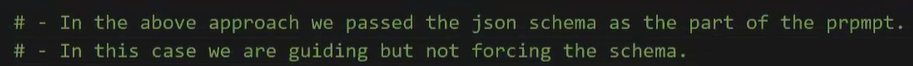

#### 2) Forcing the Schema

In [55]:
# Forcing the LLM at the generation level using the schema to give the structured output
# Generation level means when LLM is going to generate the response, then only we will tell the output format it needs to be followed.

In [39]:
prompt = ChatPromptTemplate.from_messages([
    ('system', 'You are an Data Science & AI expert.'),
    ('human', '''Explain the following algorithm {algorithm}
        Give the output.that follows the provided json schema''')
])

In [40]:
my_schema = {"name": "AlgorithmInfo",
                "schema": json_schema}

In [44]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                    model='gpt-4o-mini')

In [47]:
llm_with_schema = llm.with_structured_output(schema = my_schema) 
# this will be passed as a constraint to LLM separately (not part of the prompt).
llm_with_schema

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002C54766D090>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002C54766D1D0>, root_client=<openai.OpenAI object at 0x000002C54766CB90>, root_async_client=<openai.AsyncOpenAI object at 0x000002C54766CCD0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True), kwargs={'response_format': {'type': 'json_schema', 'json_schema': {'name': 'AlgorithmInfo', 'schema': {'type': 'object', 'propert

In [49]:
chain = prompt | llm_with_schema
chain

ChatPromptTemplate(input_variables=['algorithm'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Data Science & AI expert.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['algorithm'], input_types={}, partial_variables={}, template='Explain the following algorithm {algorithm}\n        Give the output.that follows the provided json schema'), additional_kwargs={})])
| RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resour

In [ ]:
response = chain.invoke({'algorithm': 'Random Forest'})
response # got the expected output without any output parser.

{'name': 'Random Forest', 'type': 'Supervised', 'use_cases': 2}

In [51]:
type(response)

dict

In [52]:
response = chain.invoke({'algorithm': 'Linear Regression'})
response

{'name': 'Linear Regression', 'type': 'Supervised', 'use_cases': 1}

#### 3) Using OpenAI SDK

In [56]:
from openai import OpenAI

In [58]:
client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))

In [59]:
prompt = """Explain the following algorithm: Random Forest.
Give the output as per the given Json Schema.
"""

In [63]:
response_format={"type": "json_schema",
                    "json_schema": {
                        "name": "AlgorithmInfo",
                        "schema": json_schema
                    }
                }

In [64]:
response = client.chat.completions.create(
    model = 'gpt-4o-mini',
    messages = [
        {'role': 'user', 'content': prompt}
    ],
    response_format = response_format
)

In [65]:
response

ChatCompletion(id='chatcmpl-D41GBKsRUU95dgpRIcS9R7R8PRvqk', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"name":"Random Forest","type":"Both","use_cases":1}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1769850527, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_1590f93f9d', usage=CompletionUsage(completion_tokens=15, prompt_tokens=141, total_tokens=156, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

In [69]:
res = response.choices[0].message.content
res

'{"name":"Random Forest","type":"Both","use_cases":1}'

In [70]:
json.loads(res)

{'name': 'Random Forest', 'type': 'Both', 'use_cases': 1}

In [ ]:
# At native level, OpenAI SDK performs the validations. It validates the response against the given schema.
# Langchain (2nd step - forcing the llm) has two layers of validation. 
# The first validation OpenAI will do (langchain also sends the schema in the response_format as above).
# When OpenAI gives the result in the string format, langchain fn structured_output will convert it into dictionary for us.

In [73]:
# OpenAI SDK:
    # Prompt + Json Schema -> OpenAI -> response (does server level validation) -> returns response

# Langchain
    # Chain (Prompt + Schema) -> OpenAI -> response (server level validation) -> Langchain receives the output and share with type compatibility.
    # When we use structured_output fn, we will always get a dictionary.

In [74]:
# response_format = Provider level feature (Varies provider to provider)

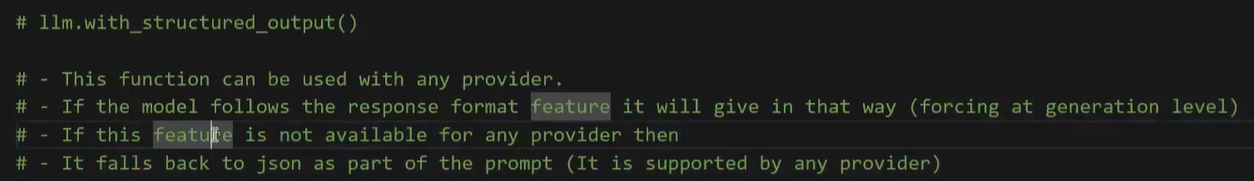